Worksheet 6

In [44]:
# CELL 1: Install dependencies (run once if needed)
# !pip install tensorflow pillow matplotlib numpy scikit-learn seaborn

In [45]:
import zipfile
import os
from tqdm import tqdm

def extract_zip_with_progress(zip_path, extract_to='/content'):
    """Extract ZIP file with a progress bar."""
    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        members = zip_ref.infolist()
        total = len(members)

        print(f"Found {total} files | Size: {sum(m.file_size for m in members) / 1e6:.1f} MB")

        for member in tqdm(members, desc="Extracting", unit="file"):
            zip_ref.extract(member, extract_to)

    print(f"Done! Files saved to: {extract_to}")

# Usage
extract_zip_with_progress('/content/drive/MyDrive/Semester6_AI ML/Week 5/Copy of FruitinAmazon.zip', '/content/output')

Found 120 files | Size: 1.2 MB


Extracting: 100%|██████████| 120/120 [00:00<00:00, 3320.93file/s]

Done! Files saved to: /content/output


In [46]:
import zipfile
import os
from tqdm import tqdm

def extract_zip_with_progress(zip_path, extract_to='/content'):
    """Extract ZIP file with a progress bar."""
    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        members = zip_ref.infolist()
        total = len(members)

        print(f"Found {total} files | Size: {sum(m.file_size for m in members) / 1e6:.1f} MB")

        for member in tqdm(members, desc="Extracting", unit="file"):
            zip_ref.extract(member, extract_to)

    print(f"Done! Files saved to: {extract_to}")

# Usage
extract_zip_with_progress('/content/drive/MyDrive/Semester6_AI ML/Week 4/Copy of devnagari digit.zip', '/content/output')

Found 20000 files | Size: 12.0 MB


Extracting: 100%|██████████| 20000/20000 [00:03<00:00, 5197.62file/s]

Done! Files saved to: /content/output


In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
# CELL 2: Import all required libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.19.0
All libraries imported successfully!


---
# Section 2.1 - Data Understanding and Visualizations
## DATASET: FruitsInAmazon
> PDF Page 2: *'We will work with the FruitsInAnazon dataset'*  
> Classes: acai, cupuacu, graviola, guarana, pupunha, tucuma

In [49]:
# CELL 3: Set path to FruitsInAmazon dataset
fruits_train_dir = "/content/output/FruitinAmazon/train"

if not os.path.exists(fruits_train_dir):
    print(f"WARNING: Path '{fruits_train_dir}' not found. Please update fruits_train_dir.")
else:
    print(f"FruitsInAmazon directory found: {fruits_train_dir}")

FruitsInAmazon directory found: /content/output/FruitinAmazon/train


In [50]:
# CELL 4: Step 1 - Read Dataset Directory and Extract Class Names
class_names = sorted(os.listdir(fruits_train_dir))
class_names = [c for c in class_names if os.path.isdir(os.path.join(fruits_train_dir, c))]

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [51]:
# CELL 5: Step 2 - Check for Corrupted Images
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(fruits_train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


In [52]:
# CELL 6: Step 3 - Count Class Balance
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(fruits_train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


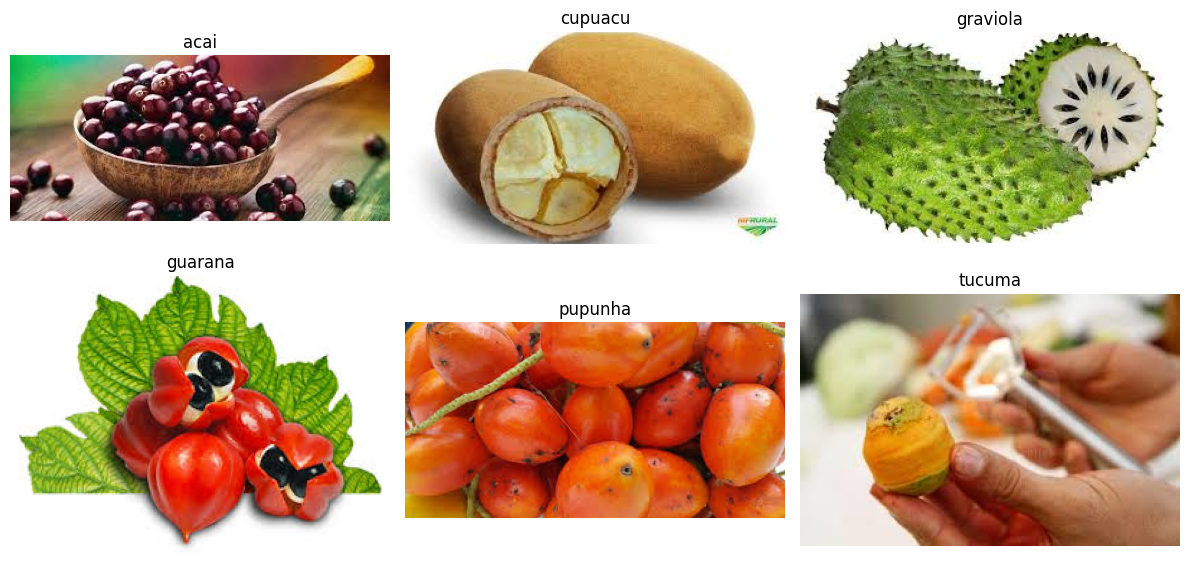

In [53]:
# CELL 7: Step 4 - Select and Visualize Random Images
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(fruits_train_dir, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

---
# Section 2.2 - Data Generation and Pre-processing
## DATASET: Devnagari Handwritten Digits
> PDF Page 6: *'For the demonstration further down I will be using Devnagari Handwritten Digits dataset from week 4'*  
> Image size: 28x28 grayscale (matches expected output on PDF page 6: Images shape: (32, 28, 28, 1))

In [54]:
# CELL 8: Set path to Devnagari Handwritten Digits dataset
devnagari_train_dir = "/content/output/DevanagariHandwrittenDigitDataset/Train"

if not os.path.exists(devnagari_train_dir):
    print(f"WARNING: Path '{devnagari_train_dir}' not found. Please update devnagari_train_dir.")
else:
    print(f"Devnagari directory found: {devnagari_train_dir}")

Devnagari directory found: /content/output/DevanagariHandwrittenDigitDataset/Train


In [55]:
# CELL 9: Generate Train and Validation Datasets
image_size = (28, 28)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    devnagari_train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    color_mode='grayscale'
)

for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Found 17000 files belonging to 10 classes.
Using 13600 files for training.
Using 3400 files for validation.
Images shape: (32, 28, 28, 1)
Labels shape: (32,)


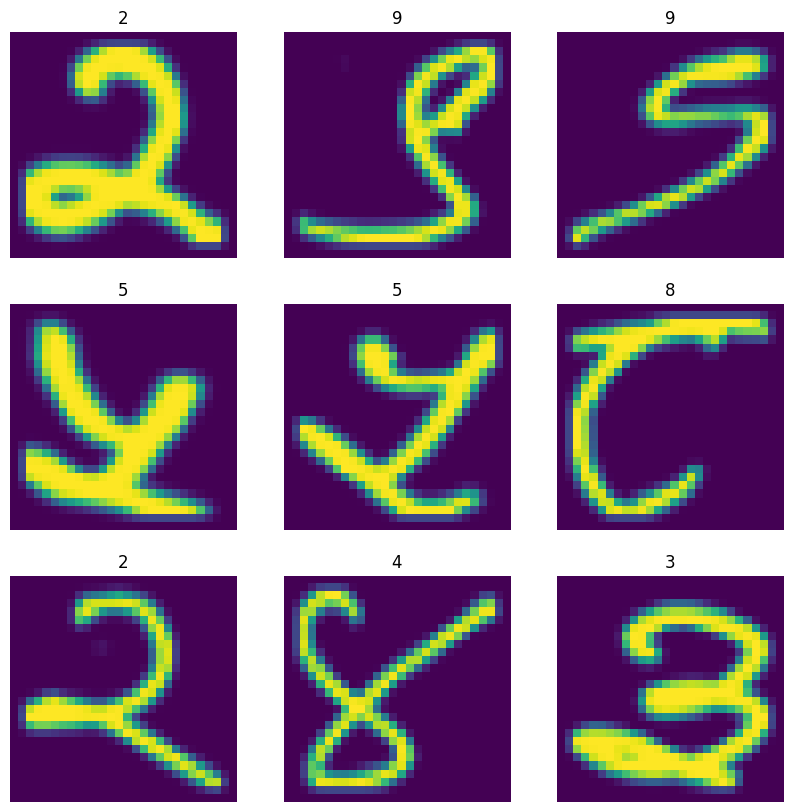

In [56]:
# CELL 10: Visualize Training Dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

### 1. Data Augmentation - Old API: ImageDataGenerator
> PDF Page 9 - shown for reference. The worksheet still demonstrates this approach.

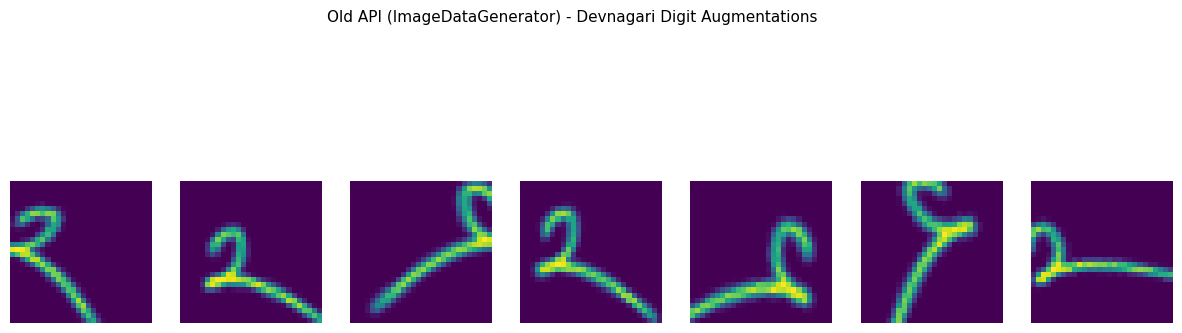

In [57]:
# CELL 11: Old API - ImageDataGenerator (Reference)
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

for images, labels in train_ds.take(1):
    sample_img = np.array(images[0]).astype("uint8")

x = np.expand_dims(sample_img, axis=0)
aug_iter = datagen.flow(x, batch_size=1)

fig, ax = plt.subplots(1, 7, figsize=(15, 5))
for i in range(7):
    batch = next(aug_iter)
    ax[i].imshow(batch[0].astype('uint8'))
    ax[i].axis('off')
plt.show()

### 2. Data Augmentation - New API: tf.keras.layers.Random*
> PDF Page 10: *'we expect you to use this for this workshop and your portfolio project'*

In [58]:
# CELL 12: New API - tf.keras.layers.Random* (Recommended)
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

print("New API augmentation defined.")

New API augmentation defined.
Key differences from ImageDataGenerator:
  1. Part of the computational graph - applied during training
  2. Can be used as part of a TensorFlow model for GPU-accelerated augmentation
  3. Augmentation is INACTIVE at test time (evaluate/predict)


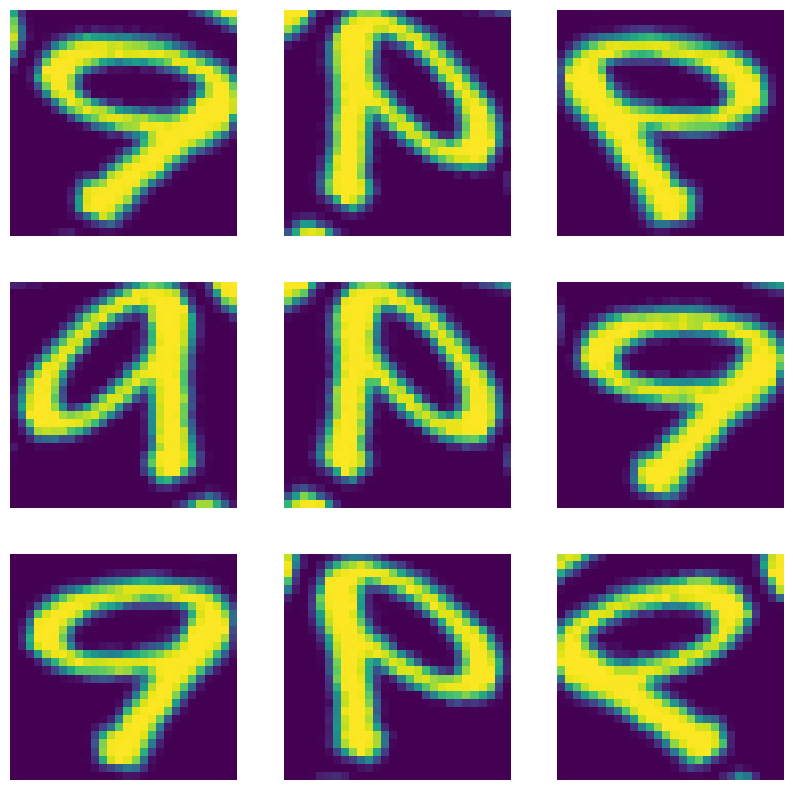

In [59]:
# CELL 13: Visualize Augmented Images with New API
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

### 3. Data Pre-processing: Rescaling
> PDF Page 11: *'RGB channel values are in the [0, 255] range... standardize values to be in the [0, 1]'*

In [60]:
# CELL 14: Data Pre-processing - Rescaling
print("Rescaling approach: Method 2 (built into model) is recommended.")

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
print("Datasets configured with cache and prefetch.")

Rescaling approach: Method 2 (built into model) is recommended.
This is used in the model architecture in Task 1 below.
Datasets configured with cache and prefetch.


---
# Section 2.3 - Model Building (Reference from Worksheet)

In [61]:
# CELL 15: Base CNN Model (Reference)
model_base_reference = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_base_reference.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_base_reference.summary()

Base model from last week (reference):


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

---
# Task 1: Improved CNN with BatchNormalization and Dropout


In [62]:
# CELL 16: TASK 1 - Get number of classes
devnagari_class_names = sorted([d for d in os.listdir(devnagari_train_dir) if os.path.isdir(os.path.join(devnagari_train_dir, d))])
NUM_DEVNAGARI_CLASSES = len(devnagari_class_names)
print(f"Number of classes: {NUM_DEVNAGARI_CLASSES}")

Devnagari class names : ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Number of classes     : 10


In [63]:
# CELL 17: TASK 1 - Build Improved CNN
model_task1 = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Lambda(data_augmentation),
    layers.Rescaling(1./255),
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    Dense(NUM_DEVNAGARI_CLASSES, activation='softmax')
])

model_task1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_task1.summary()

Model: "Improved_CNN_Task1_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 256)            │             

 Total params: 698,314 (2.66 MB)

 Trainable params: 695,434 (2.65 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [64]:
# CELL 18: TASK 1 - Understand Model Summary
total_params = model_task1.count_params()
print(f"Total Parameters: {total_params:,}")

Model Summary Analysis - Task 1
Total Parameters    : 698,314
Trainable Parameters: 695,434

How BatchNormalization works (PDF Page 13):
  Z' = (Z - mean_B) / sqrt(variance_B + epsilon)
  a' = gamma * Z' + beta
  where gamma and beta are learnable parameters

How Dropout works (PDF Page 14-15):
  X_hat = Dropout(X, r)  -- randomly zeros r fraction of neurons
  Y = X_hat / (1 - r)    -- scaled output during inference
  Conv blocks: Dropout(0.25) - drops 25% of neurons
  Dense blocks: Dropout(0.5) - drops 50% of neurons

Improvements over base model (2 Conv blocks, no BN/Dropout):
  + Data Augmentation (RandomFlip + RandomRotation)
  + Rescaling(1./255) - pixel values in [0,1]
  + 4 Conv blocks instead of 2
  + BatchNormalization after every Conv and Dense layer
  + Dropout regularization throughout


In [65]:
# CELL 19: TASK 1 - Train Model
callbacks_task1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    ModelCheckpoint(filepath='best_model.keras', save_best_only=True)
]

history_task1 = model_task1.fit(train_ds, epochs=10, validation_data=val_ds, callbacks=callbacks_task1)

Training Improved CNN on Devnagari Handwritten Digits...
-------------------------------------------------------
Epoch 1/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.1720 - loss: 2.4724
Epoch 1: val_accuracy improved from None to 0.14235, saving model to best_model_task1_devnagari.keras

Epoch 1: finished saving model to best_model_task1_devnagari.keras
425/425 ━━━━━━━━━━━━━━━━━━━━ 66s 132ms/step - accuracy: 0.2549 - loss: 2.1141 - val_accuracy: 0.1424 - val_loss: 3.2735 - learning_rate: 0.0010
Epoch 2/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.4634 - loss: 1.4758
Epoch 2: val_accuracy improved from 0.14235 to 0.77000, saving model to best_model_task1_devnagari.keras

Epoch 2: finished saving model to best_model_task1_devnagari.keras
425/425 ━━━━━━━━━━━━━━━━━━━━ 81s 135ms/step - accuracy: 0.5052 - loss: 1.3756 - val_accuracy: 0.7700 - val_loss: 0.6850 - learning_rate: 0.0010
Epoch 3/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.6334 - loss:

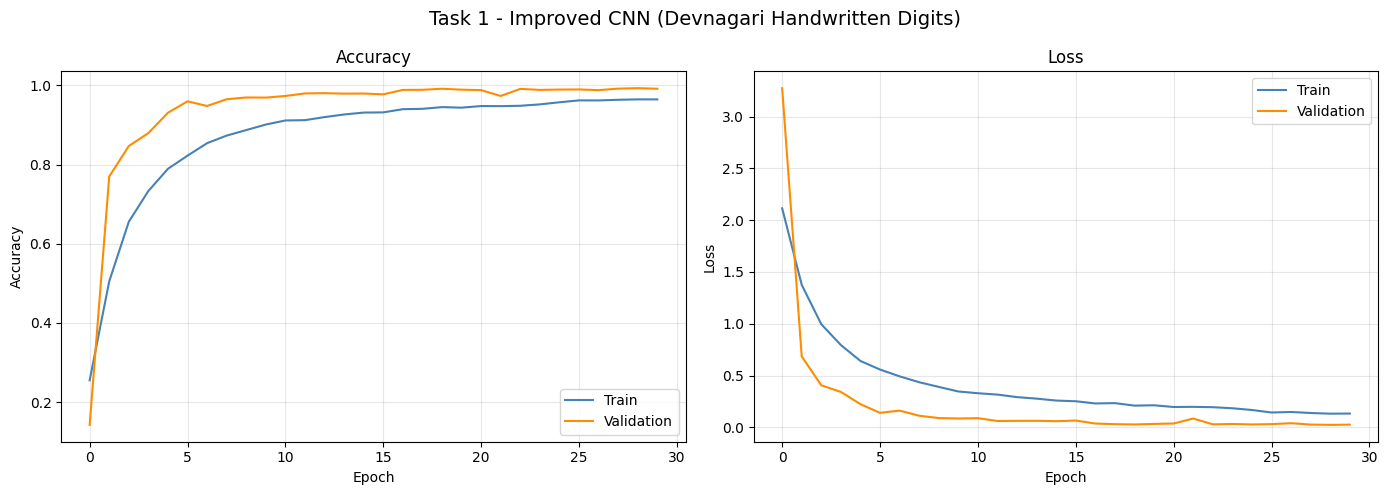

In [66]:
# ============================================================
# CELL 20: TASK 1 - Plot Training History
# DATASET: Devnagari Handwritten Digits
# ============================================================

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14)

    axes[0].plot(history.history['accuracy'],     label='Train',      color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Validation', color='darkorange')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train',      color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Validation', color='darkorange')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_task1, "Task 1 - Improved CNN (Devnagari Handwritten Digits)")

In [67]:
# ============================================================
# CELL 21: TASK 1 - Evaluate Model Performance
# DATASET: Devnagari Handwritten Digits
# ============================================================

print("=" * 50)
print("TASK 1 - Model Evaluation")
print("=" * 50)

test_loss, test_acc = model_task1.evaluate(val_ds, verbose=0)
print(f"Validation Loss    : {test_loss:.4f}")
print(f"Validation Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

TASK 1 - Model Evaluation
Validation Loss    : 0.0243
Validation Accuracy: 0.9932 (99.32%)


In [68]:
# ============================================================
# CELL 22: TASK 1 - Make Predictions and Interpret Results
# DATASET: Devnagari Handwritten Digits
# PDF Page 16: 'Make Predictions and Interpret Results'
# ============================================================

y_true_task1 = []
y_pred_task1 = []

for images, labels in val_ds:
    preds = model_task1.predict(images, verbose=0)
    y_pred_task1.extend(np.argmax(preds, axis=1))
    y_true_task1.extend(labels.numpy())

y_true_task1 = np.array(y_true_task1)
y_pred_task1 = np.array(y_pred_task1)

print("=" * 55)
print("TASK 1 - Classification Report (Devnagari Digits)")
print("=" * 55)
print(classification_report(y_true_task1, y_pred_task1,
                             target_names=devnagari_class_names))

TASK 1 - Classification Report (Devnagari Digits)
              precision    recall  f1-score   support

     digit_0       1.00      1.00      1.00       356
     digit_1       1.00      1.00      1.00       350
     digit_2       0.99      0.98      0.98       338
     digit_3       0.99      0.98      0.98       336
     digit_4       1.00      1.00      1.00       353
     digit_5       0.99      1.00      1.00       346
     digit_6       0.98      0.99      0.99       345
     digit_7       1.00      0.98      0.99       315
     digit_8       1.00      1.00      1.00       320
     digit_9       1.00      0.99      1.00       341

    accuracy                           0.99      3400
   macro avg       0.99      0.99      0.99      3400
weighted avg       0.99      0.99      0.99      3400



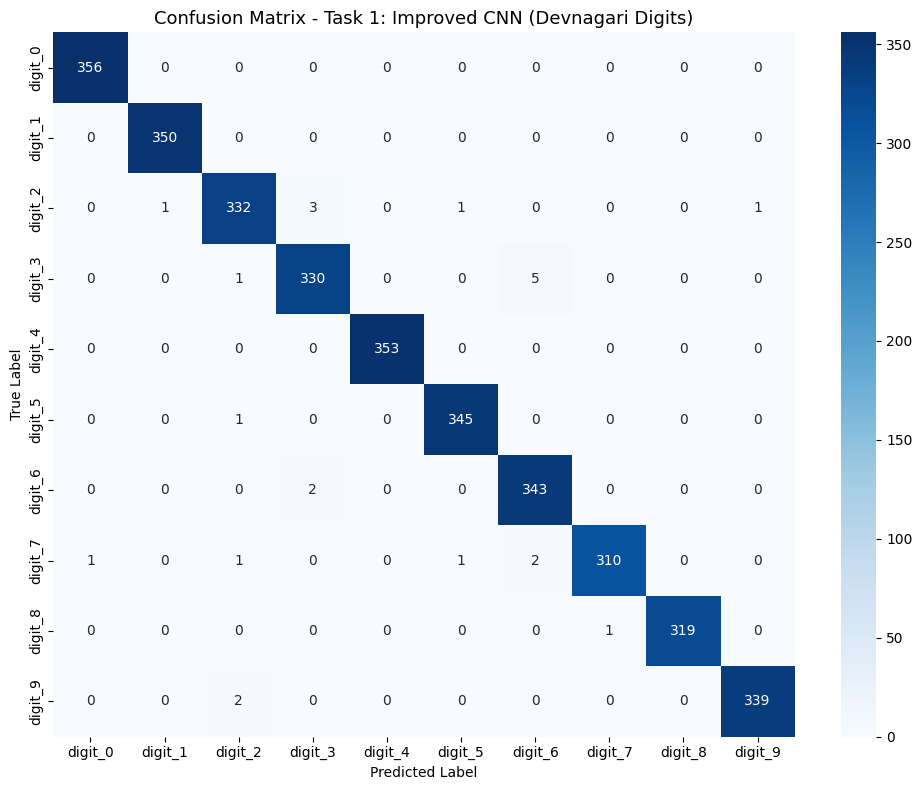

In [69]:
# ============================================================
# CELL 23: TASK 1 - Confusion Matrix
# DATASET: Devnagari Handwritten Digits
# ============================================================

cm_task1 = confusion_matrix(y_true_task1, y_pred_task1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_task1, annot=True, fmt='d', cmap='Blues',
    xticklabels=devnagari_class_names,
    yticklabels=devnagari_class_names
)
plt.title('Confusion Matrix - Task 1: Improved CNN (Devnagari Digits)', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

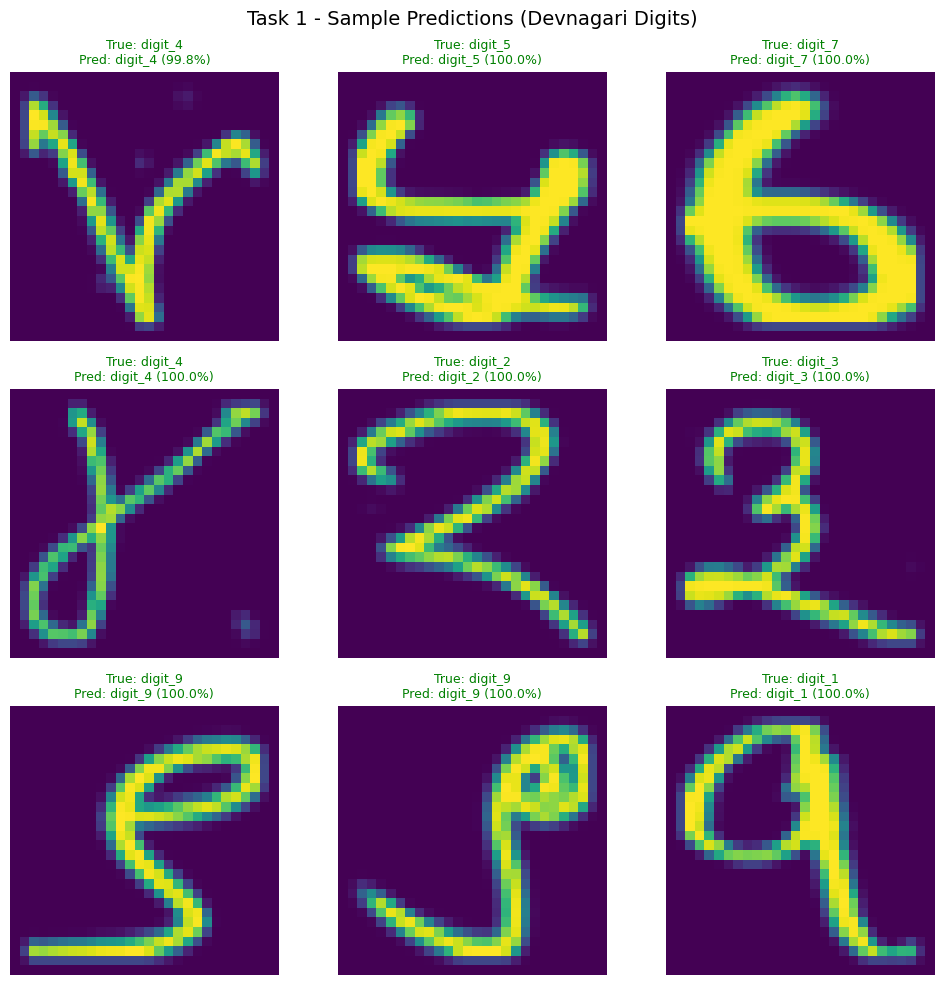

In [70]:

# CELL 24: TASK 1 - Visualize Sample Predictions
# DATASET: Devnagari Handwritten Digits


for images, labels in val_ds.take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()

preds        = model_task1.predict(images[:9], verbose=0)
pred_classes = np.argmax(preds, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Task 1 - Sample Predictions (Devnagari Digits)', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].astype('uint8'))
    true_lbl = devnagari_class_names[sample_labels[i]]
    pred_lbl = devnagari_class_names[pred_classes[i]]
    conf     = preds[i][pred_classes[i]] * 100
    color    = 'green' if true_lbl == pred_lbl else 'red'
    ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.1f}%)",
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [71]:

# CELL 25: TASK 1 - Training Behavior Analysis
# DATASET: Devnagari Handwritten Digits
# PDF Page 16: 'Understand the Model Summary and Training Behavior'


best_epoch    = np.argmax(history_task1.history['val_accuracy']) + 1
best_val_acc  = max(history_task1.history['val_accuracy'])
final_trn_acc = history_task1.history['accuracy'][-1]
gap           = final_trn_acc - best_val_acc

print("=" * 55)
print("Training Behavior Analysis - Task 1")
print("=" * 55)
print(f"Best Epoch              : {best_epoch}")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Final Train Accuracy    : {final_trn_acc*100:.2f}%")
print(f"Train-Val Gap           : {gap:.4f}")
print()

if gap > 0.1:
    print("Observation: Some overfitting detected.")
    print("BatchNorm + Dropout are helping. Consider more augmentation.")
else:
    print("Observation: Good generalization.")
    print("BatchNorm stabilized training; Dropout effectively prevented overfitting.")

Training Behavior Analysis - Task 1
Best Epoch              : 29
Best Validation Accuracy: 99.32%
Final Train Accuracy    : 96.49%
Train-Val Gap           : -0.0284

Observation: Good generalization.
BatchNorm stabilized training; Dropout effectively prevented overfitting.


---
# Task 2: Transfer Learning with VGG16


In [72]:

# CELL 26: TASK 2 - Prepare FruitsInAmazon Dataset for VGG16


VGG_IMAGE_SIZE = (224, 224)
VGG_BATCH_SIZE = 32

# One-hot labels needed for categorical_crossentropy
train_ds_fruits, val_ds_fruits = keras.utils.image_dataset_from_directory(
    fruits_train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=VGG_IMAGE_SIZE,     # 224x224 required by VGG16
    batch_size=VGG_BATCH_SIZE,
    label_mode='categorical'       # One-hot for categorical_crossentropy
)

FRUITS_CLASS_NAMES = train_ds_fruits.class_names
NUM_FRUITS_CLASSES = len(FRUITS_CLASS_NAMES)

print(f"FruitsInAmazon for VGG16:")
print(f"  Image size  : {VGG_IMAGE_SIZE}")
print(f"  Classes     : {FRUITS_CLASS_NAMES}")
print(f"  Num classes : {NUM_FRUITS_CLASSES}")

train_ds_fruits = train_ds_fruits.cache().shuffle(500).prefetch(AUTOTUNE)
val_ds_fruits   = val_ds_fruits.cache().prefetch(AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
FruitsInAmazon for VGG16:
  Image size  : (224, 224)
  Classes     : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
  Num classes : 6


In [73]:

# CELL 27: TASK 2 - Step 1: Load Pre-trained VGG16


# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(
    weights='imagenet',        # Pre-trained on ImageNet
    include_top=False,         # Exclude final dense classification layers
    input_shape=(224, 224, 3)  # Must match our input shape
)

print("VGG16 loaded with ImageNet weights.")
print(f"Total layers: {len(base_model.layers)}")
print(f"Output shape: {base_model.output_shape}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
VGG16 loaded with ImageNet weights.
Total layers: 19
Output shape: (None, 7, 7, 512)


In [74]:

# CELL 28: TASK 2 - Step 2: Freeze the Layers


# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

frozen    = sum(1 for l in base_model.layers if not l.trainable)
trainable = sum(1 for l in base_model.layers if l.trainable)

print(f"Frozen layers   : {frozen}")
print(f"Trainable layers: {trainable}")
print("All VGG16 layers frozen - ImageNet knowledge is preserved.")

Frozen layers   : 19
Trainable layers: 0
All VGG16 layers frozen - ImageNet knowledge is preserved.


In [75]:

# CELL 29: TASK 2 - Step 3: Add Custom Layers


# Add custom layers on top of the pre-trained model
x = base_model.output
x = GlobalAveragePooling2D()(x)          # Reduces (7,7,512) -> (512,)
x = Dense(1024, activation='relu')(x)    # Fully connected with 1024 neurons
x = Dense(NUM_FRUITS_CLASSES,
          activation='softmax')(x)       # Output layer for 6 fruit classes

print("Custom head added:")
print(f"  GlobalAveragePooling2D : (7,7,512) -> (512,)")
print(f"  Dense(1024, relu)")
print(f"  Dense({NUM_FRUITS_CLASSES}, softmax) -> {FRUITS_CLASS_NAMES}")

Custom head added:
  GlobalAveragePooling2D : (7,7,512) -> (512,)
  Dense(1024, relu)
  Dense(6, softmax) -> ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [76]:

# CELL 30: TASK 2 - Step 4: Create the Final Model


# Create the final model
model_vgg = Model(
    inputs=base_model.input,
    outputs=x
)

# Compile the model - matches worksheet page 18
model_vgg.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

total_p     = model_vgg.count_params()
trainable_p = sum([tf.size(v).numpy() for v in model_vgg.trainable_variables])
frozen_p    = total_p - trainable_p

print(f"\nTotal parameters     : {total_p:,}")
print(f"Trainable parameters : {trainable_p:,}  (custom head only)")
print(f"Frozen parameters    : {frozen_p:,}  (VGG16 backbone)")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Total parameters     : 15,246,150
Trainable parameters : 531,462  (custom head only)
Frozen parameters    : 14,714,688  (VGG16 backbone)


In [77]:

# CELL 31: TASK 2 - Step 5: Compile and Fit the Model


callbacks_vgg = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model_vgg16_fruits.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

EPOCHS_VGG = 25

print("Training VGG16 Transfer Learning on FruitsInAmazon...")
print("-" * 55)

history_vgg = model_vgg.fit(
    train_ds_fruits,
    epochs=EPOCHS_VGG,
    validation_data=val_ds_fruits,
    callbacks=callbacks_vgg,
    verbose=1
)

Training VGG16 Transfer Learning on FruitsInAmazon...
-------------------------------------------------------
Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.1120 - loss: 9.1293 
Epoch 1: val_accuracy improved from None to 0.22222, saving model to best_model_vgg16_fruits.keras

Epoch 1: finished saving model to best_model_vgg16_fruits.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 26s/step - accuracy: 0.2361 - loss: 9.6749 - val_accuracy: 0.2222 - val_loss: 11.8187 - learning_rate: 0.0010
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6028 - loss: 4.0956 
Epoch 2: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 25s/step - accuracy: 0.5833 - loss: 5.2330 - val_accuracy: 0.1667 - val_loss: 8.6806 - learning_rate: 0.0010
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8285 - loss: 1.4230
Epoch 3: val_accuracy improved from 0.22222 to 0.33333, saving model to best_model_vgg16_fruits.keras

Epoch 3: finished saving model to best_model_vg

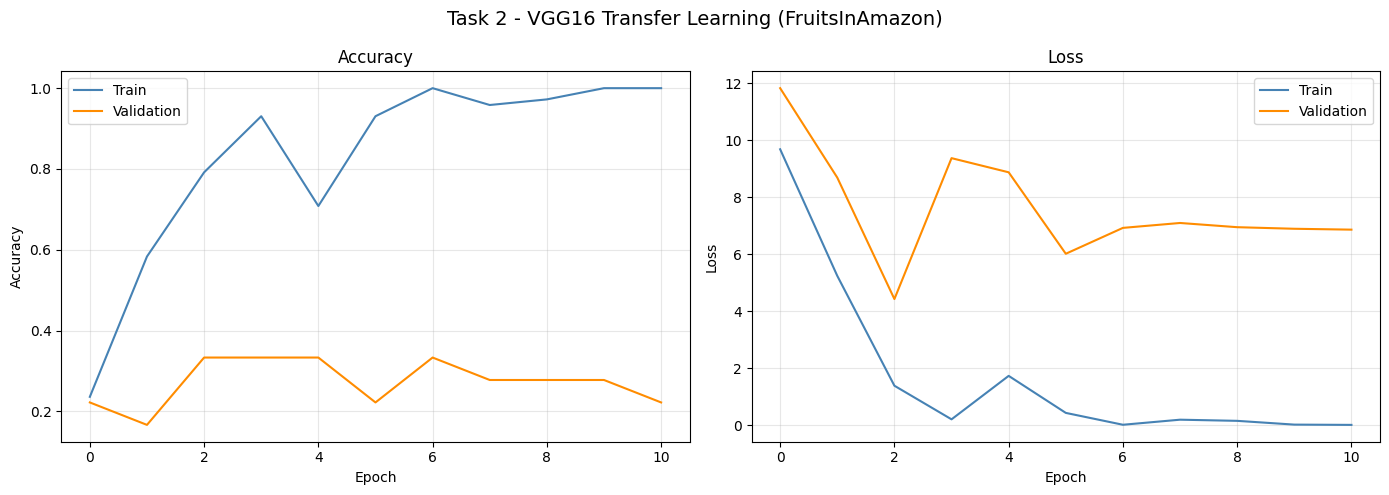

In [78]:

# CELL 32: TASK 2 - Plot Training History


plot_history(history_vgg, "Task 2 - VGG16 Transfer Learning (FruitsInAmazon)")

In [79]:

# CELL 33: TASK 2 - Evaluate Model Performance


print("=" * 55)
print("TASK 2 - VGG16 Evaluation on FruitsInAmazon")
print("=" * 55)

vgg_loss, vgg_acc = model_vgg.evaluate(val_ds_fruits, verbose=0)
print(f"Validation Loss    : {vgg_loss:.4f}")
print(f"Validation Accuracy: {vgg_acc:.4f} ({vgg_acc*100:.2f}%)")

TASK 2 - VGG16 Evaluation on FruitsInAmazon
Validation Loss    : 4.4196
Validation Accuracy: 0.3333 (33.33%)


In [80]:

# CELL 34: TASK 2 - Inference Output and Classification Report


y_true_vgg = []
y_pred_vgg = []

for images, labels in val_ds_fruits:
    preds = model_vgg.predict(images, verbose=0)
    y_pred_vgg.extend(np.argmax(preds, axis=1))
    y_true_vgg.extend(np.argmax(labels.numpy(), axis=1))

y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)

print("=" * 60)
print("TASK 2 - Classification Report (VGG16 on FruitsInAmazon)")
print("=" * 60)
print(classification_report(y_true_vgg, y_pred_vgg,
                             target_names=FRUITS_CLASS_NAMES))

TASK 2 - Classification Report (VGG16 on FruitsInAmazon)
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.75      0.75      0.75         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.40      0.50      0.44         4
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.33        18
   macro avg       0.36      0.24      0.25        18
weighted avg       0.53      0.33      0.36        18



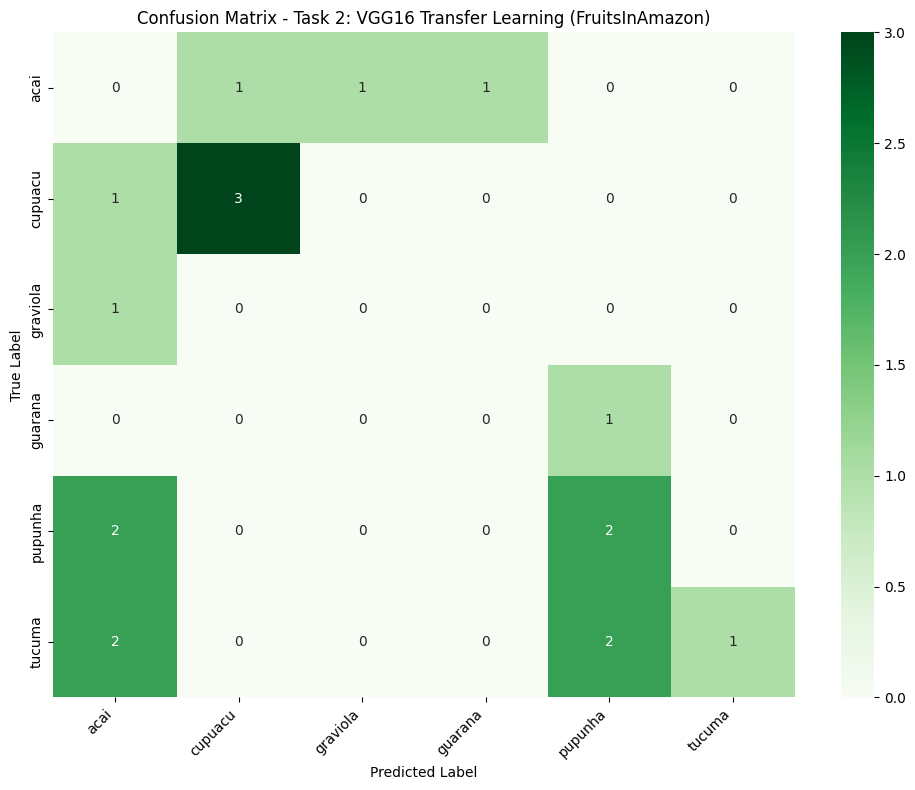

In [81]:

# CELL 35: TASK 2 - Confusion Matrix


cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_vgg, annot=True, fmt='d', cmap='Greens',
    xticklabels=FRUITS_CLASS_NAMES,
    yticklabels=FRUITS_CLASS_NAMES
)
plt.title('Confusion Matrix - Task 2: VGG16 Transfer Learning (FruitsInAmazon)', fontsize=12)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

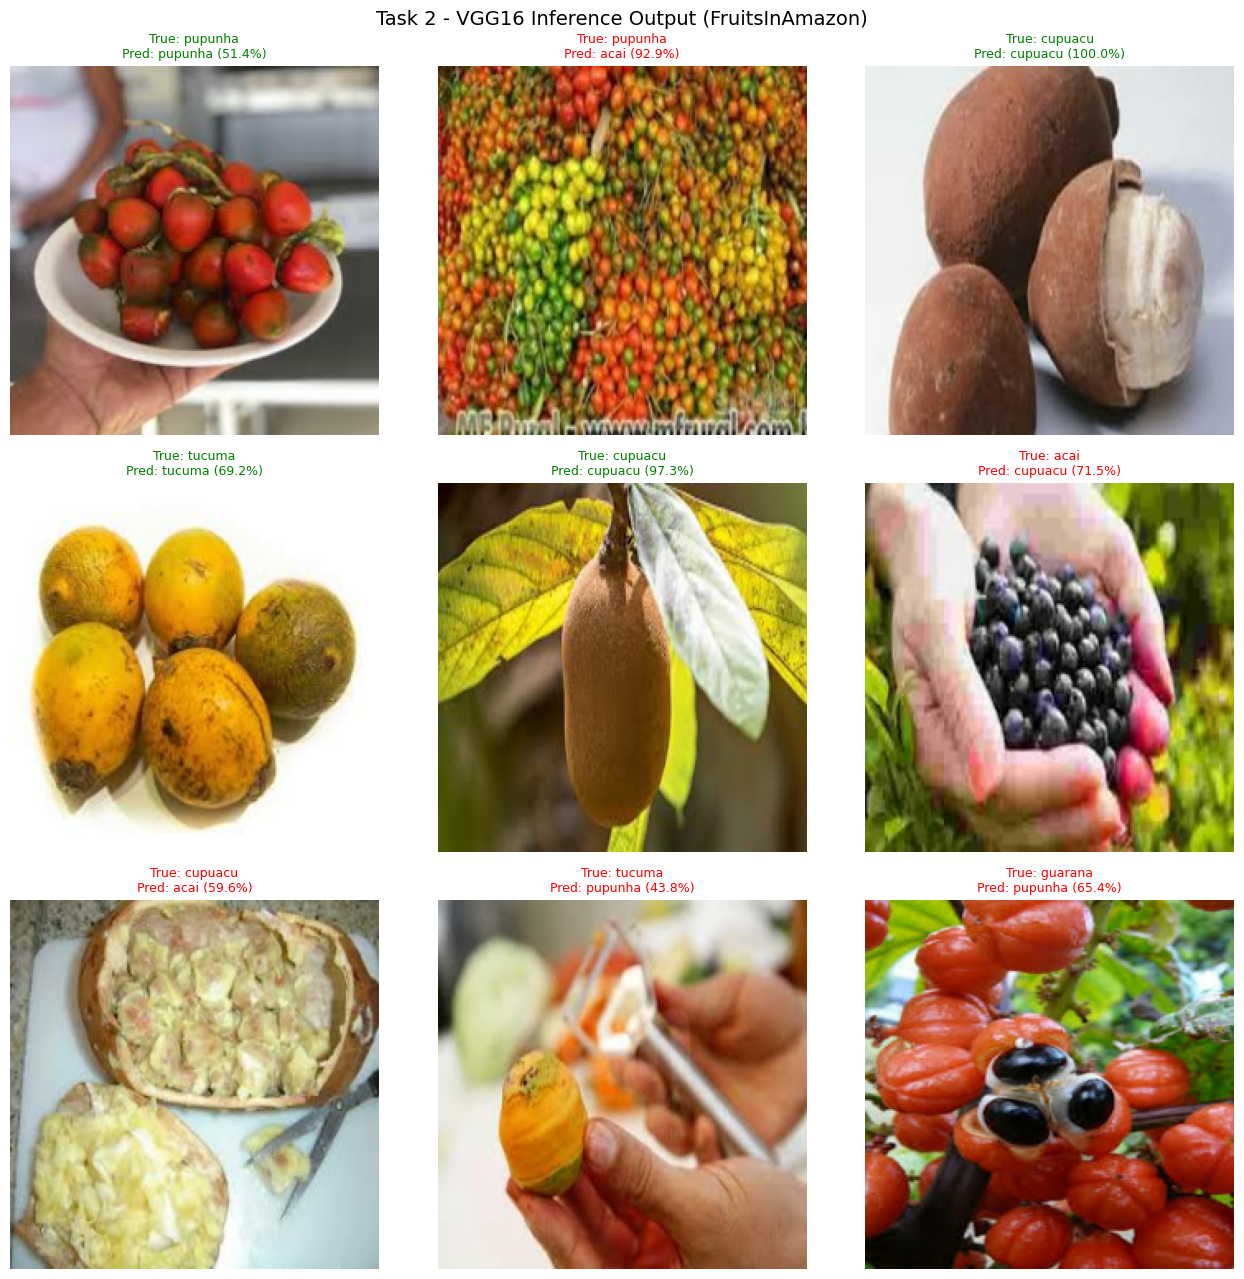

In [82]:

# CELL 36: TASK 2 - Sample Inference Output Visualization

for images, labels in val_ds_fruits.take(1):
    sample_imgs = images.numpy()
    sample_lbls = np.argmax(labels.numpy(), axis=1)

preds_vgg    = model_vgg.predict(images[:9], verbose=0)
pred_classes = np.argmax(preds_vgg, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
fig.suptitle('Task 2 - VGG16 Inference Output (FruitsInAmazon)', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i].astype('uint8'))
    true_lbl = FRUITS_CLASS_NAMES[sample_lbls[i]]
    pred_lbl = FRUITS_CLASS_NAMES[pred_classes[i]]
    conf     = preds_vgg[i][pred_classes[i]] * 100
    color    = 'green' if true_lbl == pred_lbl else 'red'
    ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.1f}%)",
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [83]:

# CELL 37: TASK 2 - Compare scratch CNN vs VGG16 on FruitsInAmazon


# Re-load FruitsInAmazon with integer labels for scratch CNN
scratch_train_ds, scratch_val_ds = keras.utils.image_dataset_from_directory(
    fruits_train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(224, 224),
    batch_size=32,
    label_mode='int'
)
scratch_train_ds = scratch_train_ds.cache().prefetch(AUTOTUNE)
scratch_val_ds   = scratch_val_ds.cache().prefetch(AUTOTUNE)

# Simple scratch CNN on FruitsInAmazon for comparison
model_scratch = Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),
    Conv2D(32, (3,3), padding='same'), BatchNormalization(), Activation('relu'),
    MaxPooling2D(), Dropout(0.25),
    Conv2D(64, (3,3), padding='same'), BatchNormalization(), Activation('relu'),
    MaxPooling2D(), Dropout(0.25),
    Conv2D(128, (3,3), padding='same'), BatchNormalization(), Activation('relu'),
    MaxPooling2D(), Dropout(0.25),
    Flatten(),
    Dense(256), BatchNormalization(), Activation('relu'), Dropout(0.5),
    Dense(NUM_FRUITS_CLASSES, activation='softmax')
], name="Scratch_CNN_FruitsInAmazon")

model_scratch.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Scratch CNN on FruitsInAmazon for comparison...")
history_scratch = model_scratch.fit(
    scratch_train_ds,
    epochs=20,
    validation_data=scratch_val_ds,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=5,
                             restore_best_weights=True, verbose=0)],
    verbose=1
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Training Scratch CNN on FruitsInAmazon for comparison...
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.2083 - loss: 2.7566 - val_accuracy: 0.1667 - val_loss: 3.0613
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.7083 - loss: 0.8030 - val_accuracy: 0.1111 - val_loss: 2.7167
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.8056 - loss: 0.5118 - val_accuracy: 0.0556 - val_loss: 2.3149
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.8611 - loss: 0.4883 - val_accuracy: 0.3333 - val_loss: 2.0703
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.9722 - loss: 0.2251 - val_accuracy: 0.3333 - val_loss: 2.0604
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.9861 - loss: 0.1466 - val_accuracy: 0.3333 - val_loss: 2.0503
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 1.0000 - loss: 0.1292 - val_accuracy: 0.

In [84]:

# CELL 38: TASK 2 - Performance Comparison Results

scratch_loss, scratch_acc = model_scratch.evaluate(scratch_val_ds, verbose=0)

print("=" * 65)
print("   PERFORMANCE COMPARISON ON FruitsInAmazon")
print("=" * 65)
print(f"{'Model':<40} {'Val Accuracy':>12} {'Val Loss':>10}")
print("-" * 65)
print(f"{'Scratch CNN (trained from scratch)':<40} "
      f"{scratch_acc*100:>11.2f}% {scratch_loss:>10.4f}")
print(f"{'VGG16 Transfer Learning (frozen)':<40} "
      f"{vgg_acc*100:>11.2f}% {vgg_loss:>10.4f}")
print("=" * 65)

improvement = (vgg_acc - scratch_acc) * 100
print(f"\nAccuracy improvement with Transfer Learning: {improvement:+.2f}%")
print()
print("Answer to PDF Question: Did performance improve compared to scratch?")
if vgg_acc > scratch_acc:
    print("  YES - VGG16 Transfer Learning outperforms the scratch CNN.")
    print("  Reasons:")
    print("    1. VGG16 pre-trained on 1.2M ImageNet images - rich feature knowledge")
    print("    2. Only small custom head trained - far less overfitting risk")
    print("    3. ImageNet low-level features (edges, textures) transfer to fruit images")
else:
    print("  Scratch CNN performed comparably.")
    print("  Consider unfreezing last few VGG16 layers for fine-tuning.")

   PERFORMANCE COMPARISON ON FruitsInAmazon
Model                                    Val Accuracy   Val Loss
-----------------------------------------------------------------
Scratch CNN (trained from scratch)             33.33%     2.0703
VGG16 Transfer Learning (frozen)               33.33%     4.4196

Accuracy improvement with Transfer Learning: +0.00%

Answer to PDF Question: Did performance improve compared to scratch?
  Scratch CNN performed comparably.
  Consider unfreezing last few VGG16 layers for fine-tuning.


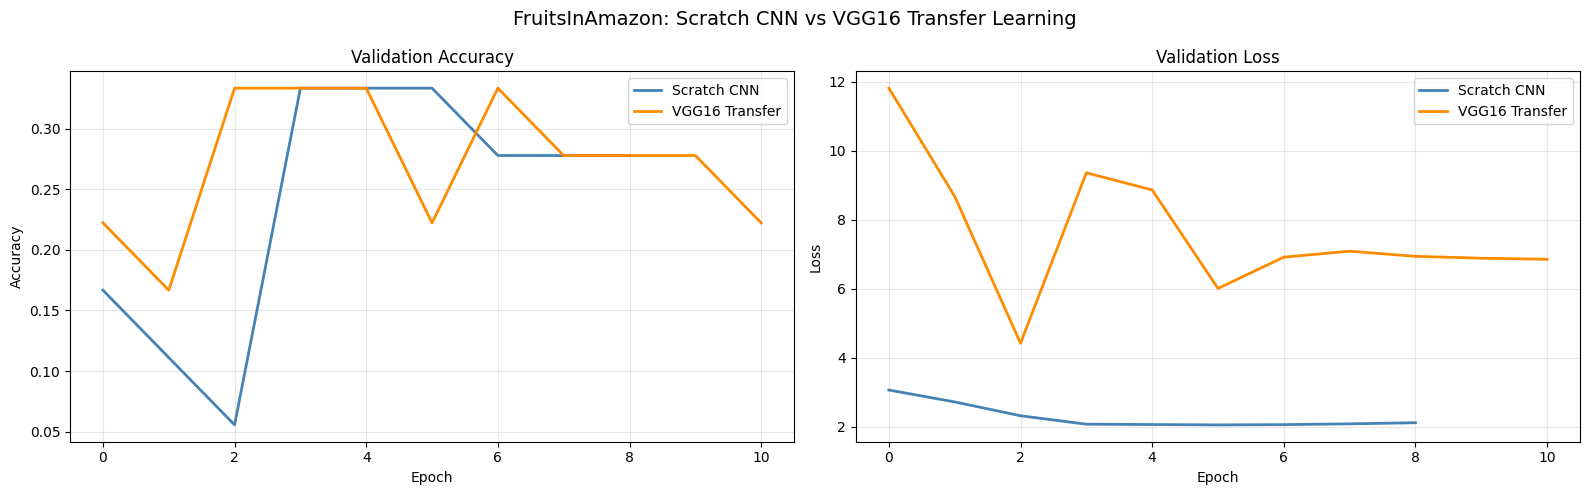

In [85]:

# CELL 39: TASK 2 - Side-by-Side Training Curve Comparison


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('FruitsInAmazon: Scratch CNN vs VGG16 Transfer Learning', fontsize=14)

axes[0].plot(history_scratch.history['val_accuracy'],
             label='Scratch CNN', color='steelblue', linewidth=2)
axes[0].plot(history_vgg.history['val_accuracy'],
             label='VGG16 Transfer', color='darkorange', linewidth=2)
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_scratch.history['val_loss'],
             label='Scratch CNN', color='steelblue', linewidth=2)
axes[1].plot(history_vgg.history['val_loss'],
             label='VGG16 Transfer', color='darkorange', linewidth=2)
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [86]:

# CELL 40: Save All Models


model_task1.save('model_task1_improved_cnn_devnagari.keras')
print("Saved: model_task1_improved_cnn_devnagari.keras")

model_vgg.save('model_task2_vgg16_fruits.keras')
print("Saved: model_task2_vgg16_fruits.keras")

model_scratch.save('model_task2_scratch_cnn_fruits.keras')
print("Saved: model_task2_scratch_cnn_fruits.keras")

print("\nAll models saved successfully!")

Saved: model_task1_improved_cnn_devnagari.keras
Saved: model_task2_vgg16_fruits.keras
Saved: model_task2_scratch_cnn_fruits.keras

All models saved successfully!
